In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm.notebook import tqdm

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

In [2]:
import os
S3_USER_STORAGE_KEY = os.environ["S3_USER_STORAGE_KEY"]
S3_USER_STORAGE_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_USER_STORAGE_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

In [3]:
irr_store = new_data_store("s3",
                       root=S3_USER_STORAGE_BUCKET,
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [4]:
bbox = [-11.05, 34.75, 50.05, 72.05] # Europe
# time_range = ("2016-01-01", "2025-09-30")
# time_range = ("2022-08-07", "2025-09-30")

# TODO: Still need to add the date: ('2025-08-01', '2025-08-05'), ('2025-08-31', '2025-09-04'),


time_range = ("2025-08-31", "2025-09-09")
# time_range = ("2016-01-01", "2016-01-03")

In [5]:
def split_date_range(start_date, end_date, num_days=30):
    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, "%Y-%m-%d")
    if isinstance(end_date, str):
        end_date = datetime.strptime(end_date, "%Y-%m-%d")
    
    result = []
    current = start_date
    
    while current <= end_date:
        chunk_end = min(current + timedelta(days=num_days - 1), end_date)
        result.append((current.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")))
        current = chunk_end + timedelta(days=1)
    
    return result

In [6]:
time_ranges = split_date_range(time_range[0], time_range[1], 5)
time_ranges, len(time_ranges)

([('2025-08-31', '2025-09-04'), ('2025-09-05', '2025-09-09')], 2)

In [7]:
era_store = new_data_store("s3",
                       root=os.path.join(S3_USER_STORAGE_BUCKET, "era5"),
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [8]:
cds_store = new_data_store("cds", normalize_names=True)

In [ ]:
%%time

data_id = 'reanalysis-era5-land'
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

for _time_range in tqdm(time_ranges):
    cds_cube = cds_store.open_data(
        data_id,
        cds_store.get_data_opener_ids()[0],
        variable_names=variables,
        bbox=bbox,
        spatial_res=spatial_res,
        time_range=_time_range
    )
    cds_cube=chunk_dataset(cds_cube, {"time": 60, "lat": 187, "lon": 306})
    era_store.write_data(cds_cube, f"era5-{_time_range[0].replace("-", "_")}-{_time_range[1].replace("-", "_")}.zarr", replace=True)

In [9]:
cds_cube

<xarray.Dataset> Size: 438MB
Dimensions:  (time: 120, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 960B 2025-07-27 ... 2025-07-31T23:00:00
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
    number   int64 8B ...
    expver   (time) <U4 2kB dask.array<chunksize=(60,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 109MB dask.array<chunksize=(60, 187, 306), meta=np.ndarray>
    pev      (time, lat, lon) float32 109MB dask.array<chunksize=(60, 187, 306), meta=np.ndarray>
    tp       (time, lat, lon) float32 109MB dask.array<chunksize=(60, 187, 306), meta=np.ndarray>
    sf       (time, lat, lon) float32 109MB dask.array<chunksize=(60, 187, 306), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-20T05:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
set(cds_cube.expver.values)

{np.str_('0001')}

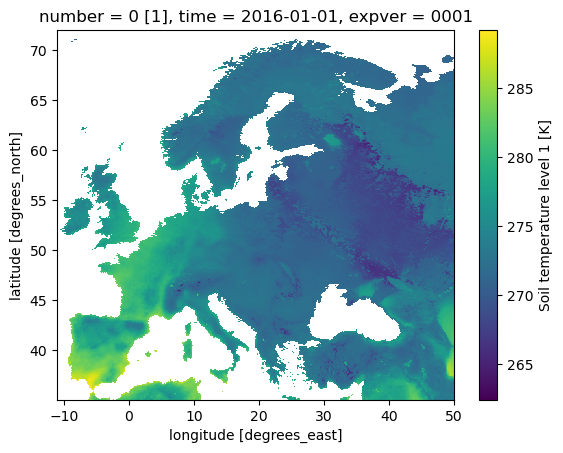

In [31]:
cds_cube.stl1.isel(time=0).plot()

In [7]:
data_ids = era_store.list_data_ids()
data_ids

['era5-2016_01_01-2016_01_05.zarr',
 'era5-2016_01_06-2016_01_10.zarr',
 'era5-2016_01_11-2016_01_15.zarr',
 'era5-2016_01_16-2016_01_20.zarr',
 'era5-2016_01_21-2016_01_25.zarr',
 'era5-2016_01_26-2016_01_30.zarr',
 'era5-2016_01_31-2016_02_04.zarr',
 'era5-2016_02_05-2016_02_09.zarr',
 'era5-2016_02_10-2016_02_14.zarr',
 'era5-2016_02_15-2016_02_19.zarr',
 'era5-2016_02_20-2016_02_24.zarr',
 'era5-2016_02_25-2016_02_29.zarr',
 'era5-2016_03_01-2016_03_05.zarr',
 'era5-2016_03_06-2016_03_10.zarr',
 'era5-2016_03_11-2016_03_15.zarr',
 'era5-2016_03_16-2016_03_20.zarr',
 'era5-2016_03_21-2016_03_25.zarr',
 'era5-2016_03_26-2016_03_30.zarr',
 'era5-2016_03_31-2016_04_04.zarr',
 'era5-2016_04_05-2016_04_09.zarr',
 'era5-2016_04_10-2016_04_14.zarr',
 'era5-2016_04_15-2016_04_19.zarr',
 'era5-2016_04_20-2016_04_24.zarr',
 'era5-2016_04_25-2016_04_29.zarr',
 'era5-2016_04_30-2016_05_04.zarr',
 'era5-2016_05_05-2016_05_09.zarr',
 'era5-2016_05_10-2016_05_14.zarr',
 'era5-2016_05_15-2016_05_19

In [ ]:
def get_dataset(data_id: str):
    print(data_id)
    ds = era_store.open_data(data_id)
    ds = ds.drop_vars(["sf", "stl1", "expver", "number"])
    if ds.sizes["time"] == 120:
        ds = ds.isel(time=[i for i in range(23, 120, 24)])
    elif ds.sizes["time"] == 24:
        ds = ds.isel(time=[-1])
    else:
        print(f"No processing done for {data_id}")
    return ds

In [10]:
%%time
datasets = []
for data_id in sorted(data_ids):
    datasets.append(get_dataset(data_id))

era5-2016_01_01-2016_01_05.zarr
era5-2016_01_06-2016_01_10.zarr
era5-2016_01_11-2016_01_15.zarr
era5-2016_01_16-2016_01_20.zarr
era5-2016_01_21-2016_01_25.zarr
era5-2016_01_26-2016_01_30.zarr
era5-2016_01_31-2016_02_04.zarr
era5-2016_02_05-2016_02_09.zarr
era5-2016_02_10-2016_02_14.zarr
era5-2016_02_15-2016_02_19.zarr
era5-2016_02_20-2016_02_24.zarr
era5-2016_02_25-2016_02_29.zarr
era5-2016_03_01-2016_03_05.zarr
era5-2016_03_06-2016_03_10.zarr
era5-2016_03_11-2016_03_15.zarr
era5-2016_03_16-2016_03_20.zarr
era5-2016_03_21-2016_03_25.zarr
era5-2016_03_26-2016_03_30.zarr
era5-2016_03_31-2016_04_04.zarr
era5-2016_04_05-2016_04_09.zarr
era5-2016_04_10-2016_04_14.zarr
era5-2016_04_15-2016_04_19.zarr
era5-2016_04_20-2016_04_24.zarr
era5-2016_04_25-2016_04_29.zarr
era5-2016_04_30-2016_05_04.zarr
era5-2016_05_05-2016_05_09.zarr
era5-2016_05_10-2016_05_14.zarr
era5-2016_05_15-2016_05_19.zarr
era5-2016_05_20-2016_05_24.zarr
era5-2016_05_25-2016_05_29.zarr
era5-2016_05_30-2016_06_03.zarr
era5-201

In [11]:
%%time
ds = xr.concat(datasets, dim="time", join="left")
ds

CPU times: user 1.07 s, sys: 84.1 ms, total: 1.15 s
Wall time: 1.13 s


<xarray.Dataset> Size: 6GB
Dimensions:  (time: 3561, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-30T23...
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 3GB dask.array<chunksize=(5, 178, 306), meta=np.ndarray>
    tp       (time, lat, lon) float32 3GB dask.array<chunksize=(5, 178, 306), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [20]:
ds = chunk_dataset(ds, {"time": 10, "lat": 178, "lon": 306}, format_name="zarr")
ds

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 3561, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-30T23...
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 3GB dask.array<chunksize=(10, 178, 306), meta=np.ndarray>
    tp       (time, lat, lon) float32 3GB dask.array<chunksize=(10, 178, 306), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [22]:
%%time
irr_store.write_data(ds, 'era5v3.zarr')

/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 1min 51s, sys: 9.62 s, total: 2min
Wall time: 6min 53s


'era5v3.zarr'

In [6]:
ds = irr_store.open_data('era5v3.zarr')
ds = chunk_dataset(ds, {"time": -1, "lat": 50, "lon": 50}, format_name="zarr")
ds

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 3561, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01T23:00:00 ... 2025-09-30T23...
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
    tp       (time, lat, lon) float32 3GB dask.array<chunksize=(3561, 50, 50), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [7]:
%%time
irr_store.write_data(ds, 'era5v3_timeopt.zarr')

CPU times: user 11.5 s, sys: 1.19 s, total: 12.7 s
Wall time: 1min 10s


'era5v3_timeopt.zarr'

In [ ]:
irr_store.delete_data('era5v3.zarr')

In [ ]:
client.shutdown()

In [ ]:
# zappend

In [27]:
total_time_steps = sum(ds.sizes['time'] for ds in datasets)
print(total_time_steps)

84000


In [ ]:
def get_dataset(data_id: str):
    ds = era_store.open_data(data_id)
    ds = ds.drop_vars(["sf", "stl1", "expver", "number"])
    ds = ds.isel(time=[i for i in range(23, 120, 24)])
    return ds

In [ ]:
datasets = []
[datasets.append(get_dataset(data_id)) for data_id in sorted(data_ids)]

In [ ]:
%%time
from zappend.api import zappend

# config = {
#     "target_dir": f"{INPUT_DIR}/era5.zarr",
#     "force_new": True,
#     "logging": True,
#     "excluded_variables": ["expver", "number"]
# }
config = {
    "target_dir": "s3://hub-deepesdl54/era5v2.zarr",
    "target_storage_options": {
        "anon": False,
        "key": S3_USER_STORAGE_KEY,
        "secret": S3_USER_STORAGE_SECRET,
    },
    "force_new": False,
    "logging": True,
    "disable_rollback": True,
    "excluded_variables": ["expver", "number"],
    "append_dim": "time",
    "variables": {
        "*": {
          "encoding": {
            "chunks": None
          }
        },
        "time": {
          "dims": ["time"],
          "encoding": {
            "chunks": [total_time_steps]
          }
        },
        "pev": {
          "dims": ["time", "lat", "lon"],
          "encoding": {
            "chunks": [total_time_steps, 15, 15],
            "dtype": "float32",  
          }
        },
        "stl1": {
          "dims": ["time", "lat", "lon"],
          "encoding": {
            "chunks": [total_time_steps, 15, 15],
            "dtype": "float32",  
          }
        },
        "tp": {
          "dims": ["time", "lat", "lon"],
          "encoding": {
            "chunks": [total_time_steps, 15, 15],
            "dtype": "float32",  
          }
        },
        "sf": {
          "dims": ["time", "lat", "lon"],
          "encoding": {
            "chunks": [total_time_steps, 15, 15],
            "dtype": "float32",  
          }
        },
    }
}
zappend(datasets, config=config)

2025-10-23 08:56:23,728 INFO Processing in-memory slice dataset #0
2025-10-23 08:56:23,783 INFO Creating target dataset s3://hub-deepesdl54/era5v2.zarr
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/zappend/processor.py:151: FutureWarning: zarr_version is deprecated, use zarr_format
  target_ds.to_zarr(
2025-10-23 08:57:31,475 INFO Transaction completed.
2025-10-23 08:57:31,476 INFO Slice dataset #0 processed
2025-10-23 08:57:31,612 INFO Processing in-memory slice dataset #1
2025-10-23 08:57:31,666 INFO Updating target dataset s3://hub-deepesdl54/era5v2.zarr
2025-10-23 08:59:53,288 INFO Transaction completed.
2025-10-23 08:59:53,290 INFO Slice dataset #1 processed
2025-10-23 08:59:53,465 INFO Processing in-memory slice dataset #2
2025-10-23 08:59:53,519 INFO Updating target dataset s3://hub-deepesdl54/era5v2.zarr
2025-10-23 09:02:15,742 INFO Transaction completed.
2025-10-23 09:02:15,743 INFO Slice dataset #2 processed
2025-10-23 09:02:15,925 

In [22]:
irr_store.list_data_ids()

['deleteme.zarr', 'era5_test.zarr', 'soil_moisture_zappend.zarr']

In [25]:
test=irr_store.open_data("era5_test.zarr")
test

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 600, lat: 373, lon: 611)
Coordinates:
  * time     (time) datetime64[ns] 5kB 2016-01-01 ... 2016-01-25T23:00:00
  * lat      (lat) float64 3kB 72.0 71.9 71.8 71.7 71.6 ... 35.1 35.0 34.9 34.8
  * lon      (lon) float64 5kB -11.0 -10.9 -10.8 -10.7 ... 49.7 49.8 49.9 50.0
Data variables:
    pev      (time, lat, lon) float32 547MB dask.array<chunksize=(600, 15, 15), meta=np.ndarray>
    sf       (time, lat, lon) float32 547MB dask.array<chunksize=(600, 15, 15), meta=np.ndarray>
    stl1     (time, lat, lon) float32 547MB dask.array<chunksize=(600, 15, 15), meta=np.ndarray>
    tp       (time, lat, lon) float32 547MB dask.array<chunksize=(600, 15, 15), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-10-17T13:43 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [24]:
0.1*111.32

11.132

In [26]:
GridMapping.from_dataset(test)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.1, 0.1)
* xy_bbox: (-11.05, 34.75, 50.05, 72.05)
* ij_bbox: (0, 0, 611, 373)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (611, 373)
* tile_size: (15, 15)